# Phantom v5: Cross-Sectional Relative Return Prediction

**Key Result**: The model achieves a **Rank IC of 0.09 at 10 days** (t-stat=11.8) on out-of-sample data,
with a **long-short Sharpe ratio of 4.55** across 413 financial assets.

This notebook provides a comprehensive analysis of the model's predictions, architecture, and performance.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t as scipy_t, spearmanr
from scripts.eval.analysis_utils import *
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 120

## 1. Model Architecture

Phantom is a Transformer-based distributional forecasting model that predicts Student-t distributions
at 30 horizons (1-30 days) simultaneously via batched cross-attention queries.

In [2]:
model, info = load_model('../checkpoints_v5/best.pt')
print(model_summary(model, info))

Phantom v5 Model Summary
Parameters:     31,707,149
Checkpoint:     step 39,000
Best val loss:  -1.4456

Encoder:
  Context:      120 days (24 patches)
  Input:        6 channels (OHLCV features)
  d_model:      512
  Layers:       8 encoder + 2 decoder
  Heads:        8
  FFN dim:      2048
  Dropout:      0.3

Decoder:
  Multi-horizon: True (30 horizons)
  Head:         student_t (Student-t, 3 params per horizon)
  Cond dropout: 0.15

Auxiliary:
  Asset classifier: 4 classes
  Vol regressor:    yes


### 1a. Architecture Diagram

Two views: a high-level block diagram showing the data flow, and a detailed computational graph.


(process:31072): Pango-WARNING **: 21:20:34.613: couldn't load font "Linux libertine Not-Rotated 10", falling back to "Sans Not-Rotated 10", expect ugly output.


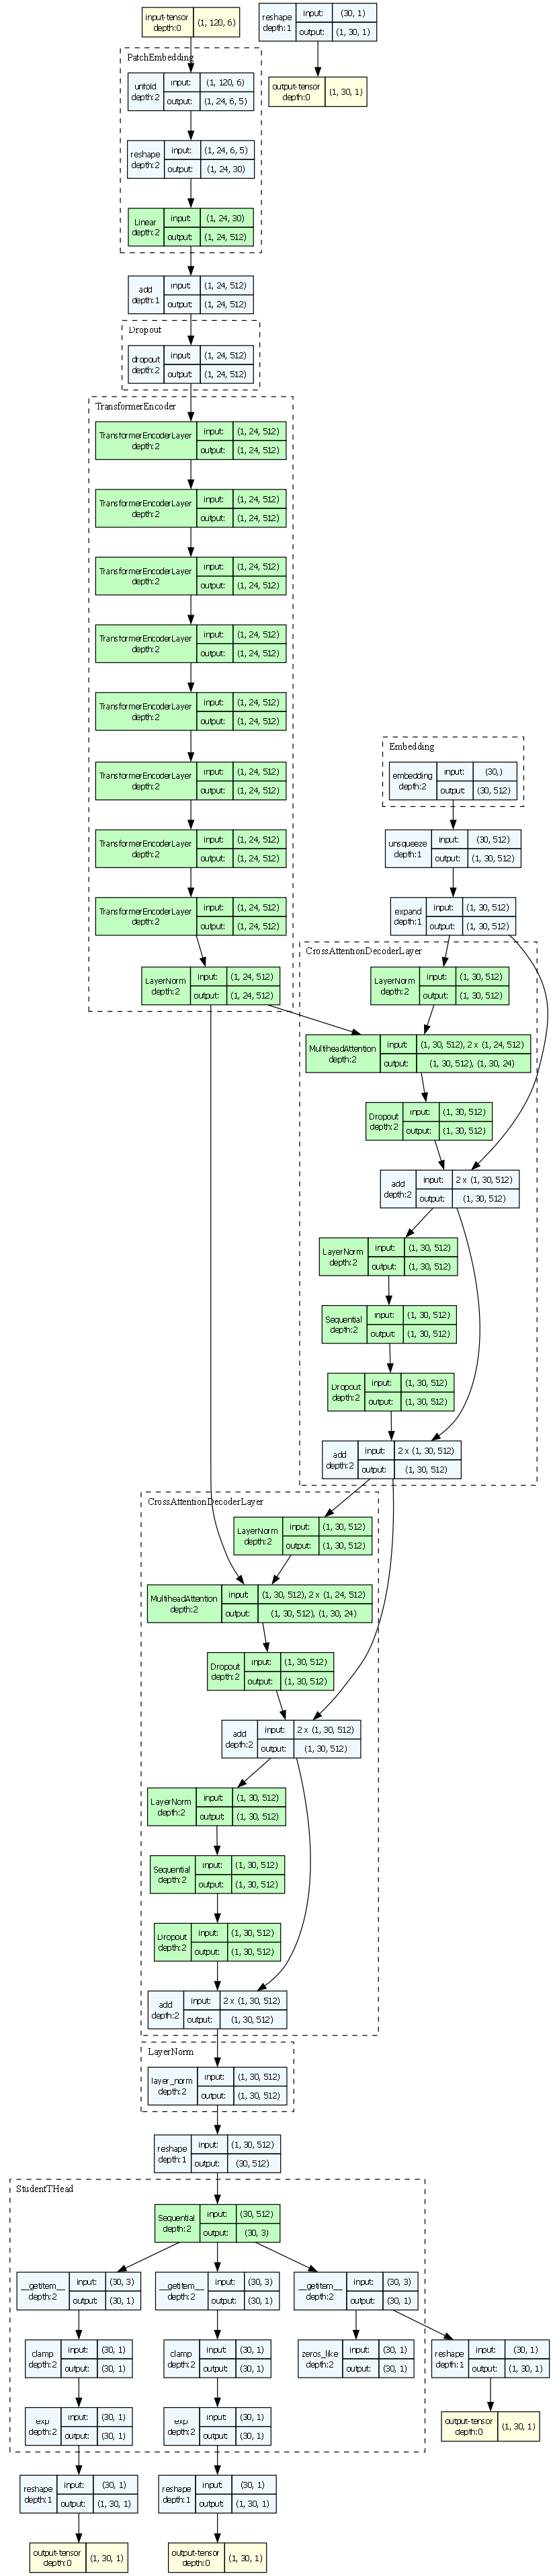

In [3]:
# --- View 3: Computational graph (torchview) ---
# Shows the actual tensor operations and layer connections
import os
os.environ['PATH'] = r'C:\Program Files\Graphviz\bin' + os.pathsep + os.environ.get('PATH', '')

try:
    import torch
    from torchview import draw_graph
    from IPython.display import Image, display
    x_dummy = torch.randn(1, 120, 6)
    graph = draw_graph(model, input_data=x_dummy, expand_nested=True, depth=2,
                       graph_name='Phantom v5', hide_inner_tensors=True,
                       hide_module_functions=False)
    png_path = graph.visual_graph.render(format='png', cleanup=True)
    display(Image(png_path))
except Exception as e:
    print(f"torchview rendering failed: {e}")
    print("Install with: pip install torchview && choco install graphviz")

## 2. Data Overview

The model was trained on **relative returns**: `Y_relative = Y_asset - mean(Y_class)` per date.
This removes shared market factors and isolates idiosyncratic (cross-sectional) signal.

- **Train**: pre-2024 (1.09M samples, 413 assets)
- **Val**: 2024 (71K samples)
- **Test**: 2025+ (81K samples) — fully out-of-sample

In [5]:
data = load_test_data('../data/processed_v5/test.npz')
meta = load_asset_meta('../data/processed_v5/asset_meta.json')

X = data['X']
Y_rel = data['Y_relative']
Y_abs = data['Y_absolute']
asset_type = data['asset_type']
dates = data['dates']
asset_id = data['asset_id']

print(f"Test set: {len(X):,} samples, {len(np.unique(dates))} unique dates")
print(f"Date range: {sorted(dates)[0]} to {sorted(dates)[-1]}")
print(f"Assets: {len(np.unique(asset_id))}")
print()
for t in sorted(np.unique(asset_type)):
    n = (asset_type == t).sum()
    print(f"  {ASSET_NAMES[t]}: {n:,} ({100*n/len(X):.1f}%)")

Test set: 81,106 samples, 429 unique dates
Date range: 2025-01-01 to 2026-03-05
Assets: 412

  Crypto: 25,740 (31.7%)
  Equity: 43,871 (54.1%)
  Forex: 4,400 (5.4%)
  Commodity: 7,095 (8.7%)


## 3. Model Predictions

In [6]:
preds = predict(model, X)
mu, sigma, nu = preds['mu'], preds['sigma'], preds['nu']

print(f"Mu:    range [{mu.min():.4f}, {mu.max():.4f}], std={mu.std():.4f}")
print(f"Sigma: range [{sigma.min():.4f}, {sigma.max():.4f}], mean={sigma.mean():.4f}")
print(f"Nu:    range [{nu.min():.2f}, {nu.max():.2f}], mean={nu.mean():.2f}")

  Batch 71/80
Mu:    range [-0.0300, 0.0046], std=0.0040
Sigma: range [0.0045, 0.2279], mean=0.0513
Nu:    range [2.01, 2.91], mean=2.11


## 4. Cross-Sectional Signal: Rank IC

The Information Coefficient (IC) measures whether the model correctly **ranks** assets
by their relative performance on each date. IC > 0 = predictive signal.

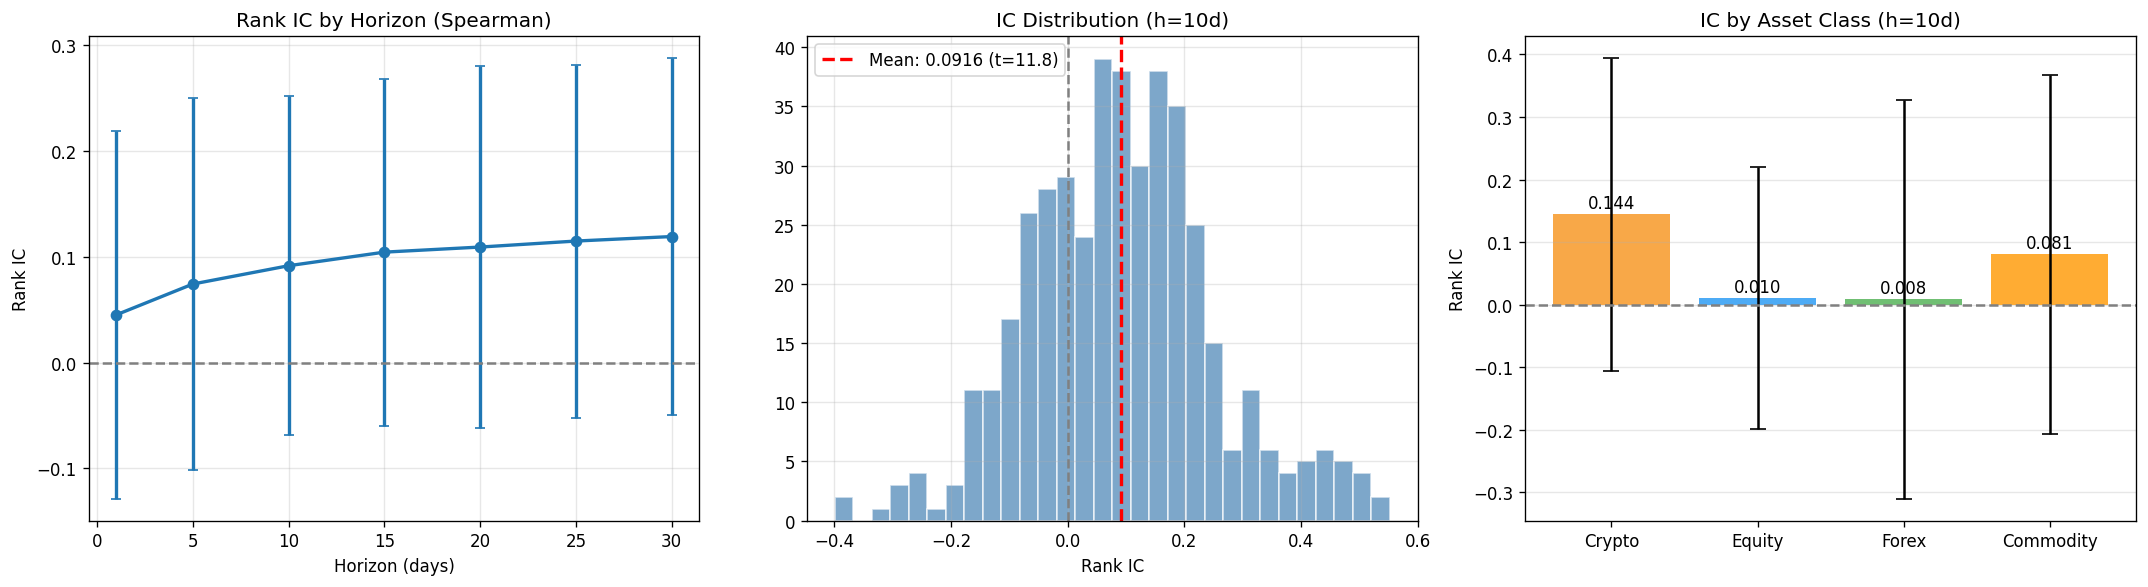


Detailed IC by horizon:
  h= 1d: IC=0.0452 +/- 0.1737, t-stat=5.4
  h= 5d: IC=0.0743 +/- 0.1761, t-stat=8.7
  h=10d: IC=0.0916 +/- 0.1602, t-stat=11.8
  h=15d: IC=0.1044 +/- 0.1639, t-stat=13.2
  h=20d: IC=0.1092 +/- 0.1708, t-stat=13.2
  h=25d: IC=0.1149 +/- 0.1667, t-stat=14.3
  h=30d: IC=0.1191 +/- 0.1687, t-stat=14.6


In [7]:
# IC by horizon
ic_results = ic_by_horizon(mu, Y_rel, dates, horizons=HORIZON_SUBSET)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: IC by horizon
h_vals = sorted(ic_results.keys())
ic_means = [ic_results[h]['mean'] for h in h_vals]
ic_stds = [ic_results[h]['std'] for h in h_vals]
axes[0].errorbar(h_vals, ic_means, yerr=ic_stds, fmt='o-', capsize=3, lw=2, ms=6)
axes[0].axhline(0, color='gray', ls='--')
axes[0].set_xlabel('Horizon (days)'); axes[0].set_ylabel('Rank IC')
axes[0].set_title('Rank IC by Horizon (Spearman)')
axes[0].grid(True, alpha=0.3)

# Panel 2: IC distribution at h=10d
ics_10d = ic_results[10]['ics']
axes[1].hist(ics_10d, bins=30, alpha=0.7, color='steelblue', edgecolor='white')
axes[1].axvline(ics_10d.mean(), color='red', ls='--', lw=2,
                label=f'Mean: {ics_10d.mean():.4f} (t={ic_results[10]["tstat"]:.1f})')
axes[1].axvline(0, color='gray', ls='--')
axes[1].set_xlabel('Rank IC'); axes[1].set_title('IC Distribution (h=10d)')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

# Panel 3: IC by asset class
ic_class = ic_by_asset_class(mu, Y_rel, dates, asset_type)
names = list(ic_class.keys())
means = [ic_class[n]['mean'] for n in names]
stds = [ic_class[n]['std'] for n in names]
colors = [ASSET_COLORS[i] for i in sorted(np.unique(asset_type))]
axes[2].bar(names, means, yerr=stds, capsize=5, color=colors, alpha=0.8)
axes[2].axhline(0, color='gray', ls='--')
for i, (n, m) in enumerate(zip(names, means)):
    axes[2].text(i, m + 0.01, f'{m:.3f}', ha='center', fontsize=10)
axes[2].set_ylabel('Rank IC'); axes[2].set_title('IC by Asset Class (h=10d)')
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\nDetailed IC by horizon:")
for h in h_vals:
    r = ic_results[h]
    print(f"  h={h:2d}d: IC={r['mean']:.4f} +/- {r['std']:.4f}, t-stat={r['tstat']:.1f}")

## 5. Long-Short Portfolio Backtest

Each day: buy the top 20% predicted outperformers, short the bottom 20%.

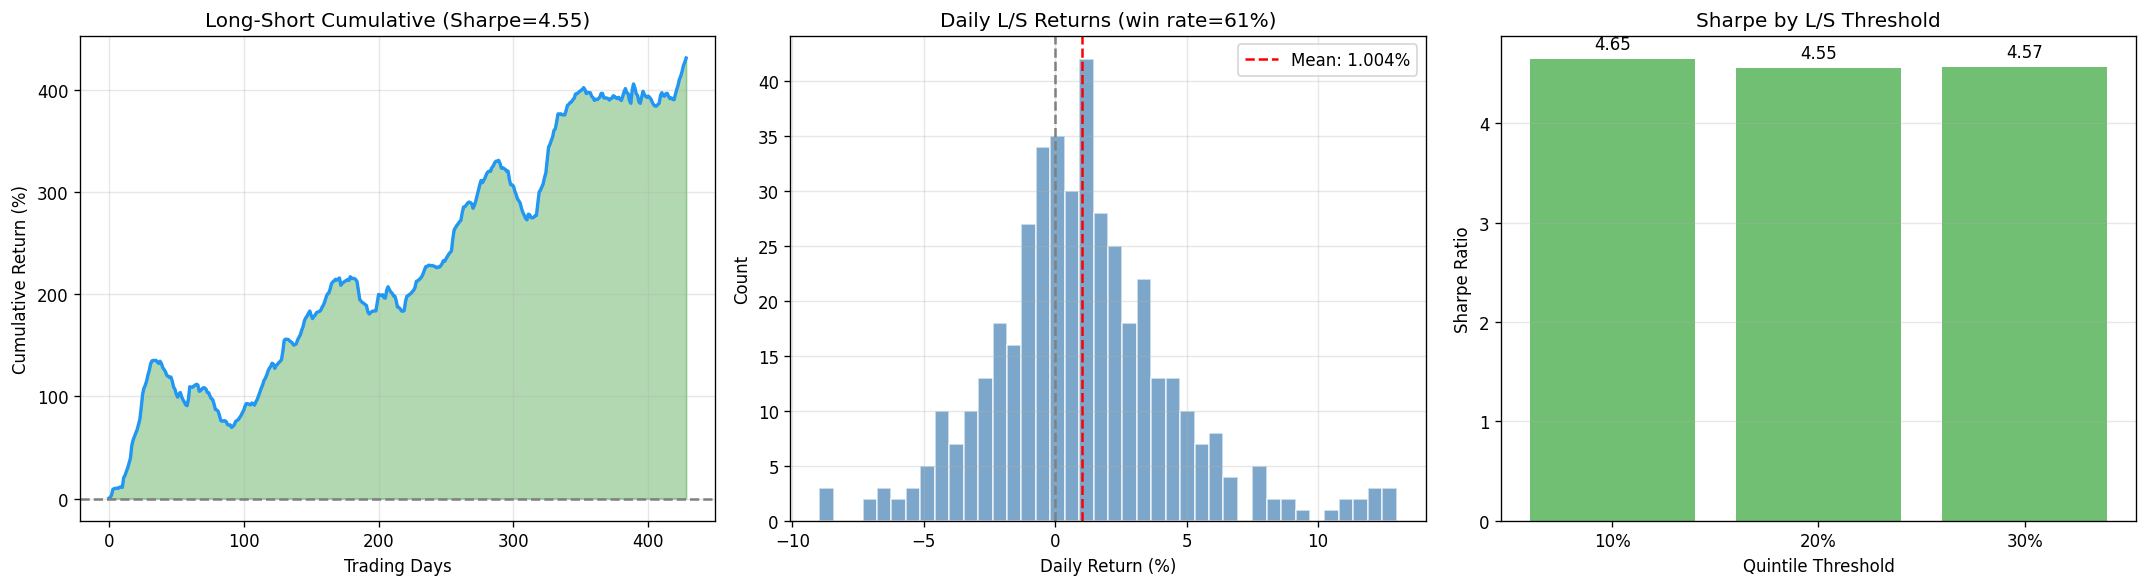


Backtest Summary (h=10d):
  Sharpe:       4.55
  Cumulative:   430.9%
  Win rate:     61%
  Max drawdown: -65.6%
  Trading days: 429


In [8]:
h_ref = 9  # 10-day horizon
bt = long_short_backtest(mu[:, h_ref], Y_rel[:, h_ref], dates)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Cumulative return
axes[0].plot(bt['cumulative'] * 100, color='#2196F3', lw=2)
axes[0].fill_between(range(len(bt['cumulative'])), 0, bt['cumulative']*100,
                     where=bt['cumulative']>=0, alpha=0.3, color='green')
axes[0].fill_between(range(len(bt['cumulative'])), 0, bt['cumulative']*100,
                     where=bt['cumulative']<0, alpha=0.3, color='red')
axes[0].axhline(0, color='gray', ls='--')
axes[0].set_xlabel('Trading Days'); axes[0].set_ylabel('Cumulative Return (%)')
axes[0].set_title(f'Long-Short Cumulative (Sharpe={bt["sharpe"]:.2f})')
axes[0].grid(True, alpha=0.3)

# Daily returns histogram
axes[1].hist(bt['daily_returns']*100, bins=40, alpha=0.7, color='steelblue', edgecolor='white')
axes[1].axvline(0, color='gray', ls='--')
axes[1].axvline(bt['mean_return']*100, color='red', ls='--',
                label=f'Mean: {bt["mean_return"]*100:.3f}%')
axes[1].set_xlabel('Daily Return (%)'); axes[1].set_ylabel('Count')
axes[1].set_title(f'Daily L/S Returns (win rate={bt["win_rate"]*100:.0f}%)')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

# Different quantile thresholds
bt_results = backtest_by_quantile(mu[:, h_ref], Y_rel[:, h_ref], dates)
qs = sorted(bt_results.keys())
sharpes = [bt_results[q]['sharpe'] for q in qs]
axes[2].bar([f'{int(q*100)}%' for q in qs], sharpes, color='#4CAF50', alpha=0.8)
for i, (q, s) in enumerate(zip(qs, sharpes)):
    axes[2].text(i, s + 0.1, f'{s:.2f}', ha='center')
axes[2].set_xlabel('Quintile Threshold'); axes[2].set_ylabel('Sharpe Ratio')
axes[2].set_title('Sharpe by L/S Threshold')
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\nBacktest Summary (h=10d):")
print(f"  Sharpe:       {bt['sharpe']:.2f}")
print(f"  Cumulative:   {bt['cumulative'][-1]*100:.1f}%")
print(f"  Win rate:     {bt['win_rate']*100:.0f}%")
print(f"  Max drawdown: {bt['max_drawdown']*100:.1f}%")
print(f"  Trading days: {bt['n_days']}")

## 6. Distributional Calibration

Does the model's uncertainty (sigma, nu) match reality?

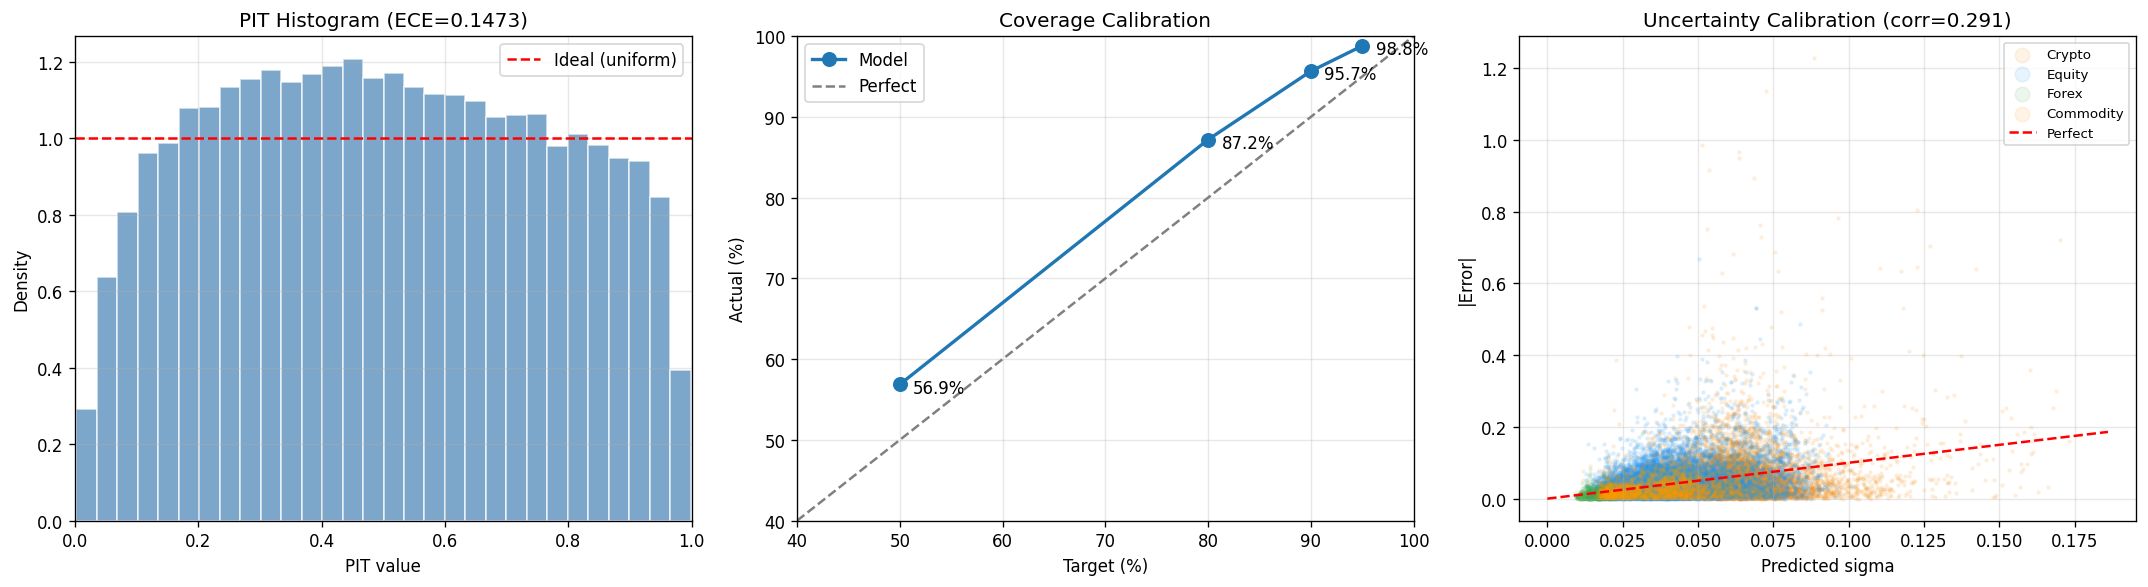

In [9]:
h_ref = 9
pit = compute_pit(Y_rel[:, h_ref], mu[:, h_ref], sigma[:, h_ref], nu[:, h_ref])
coverages = compute_coverage(Y_rel[:, h_ref], mu[:, h_ref], sigma[:, h_ref], nu[:, h_ref])
ece = compute_ece(pit)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# PIT histogram
axes[0].hist(pit, bins=30, density=True, alpha=0.7, color='steelblue', edgecolor='white')
axes[0].axhline(1.0, color='red', ls='--', lw=1.5, label='Ideal (uniform)')
axes[0].set_xlabel('PIT value'); axes[0].set_ylabel('Density')
axes[0].set_title(f'PIT Histogram (ECE={ece:.4f})')
axes[0].legend(); axes[0].grid(True, alpha=0.3); axes[0].set_xlim(0, 1)

# Coverage calibration
levels = sorted(coverages.keys())
actual = [coverages[l]*100 for l in levels]
target = [l*100 for l in levels]
axes[1].plot(target, actual, 'o-', color='tab:blue', ms=8, lw=2, label='Model')
axes[1].plot([40, 100], [40, 100], '--', color='gray', label='Perfect')
for t, a in zip(target, actual):
    axes[1].annotate(f'{a:.1f}%', (t, a), textcoords='offset points', xytext=(8, -5))
axes[1].set_xlabel('Target (%)'); axes[1].set_ylabel('Actual (%)')
axes[1].set_title('Coverage Calibration')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(40, 100); axes[1].set_ylim(40, 100)

# Uncertainty calibration (sigma vs |error|)
errors = np.abs(Y_rel[:, h_ref] - mu[:, h_ref])
corr = np.corrcoef(sigma[:, h_ref], errors)[0, 1]
for t in sorted(np.unique(asset_type)):
    mask = asset_type == t
    axes[2].scatter(sigma[mask, h_ref][::3], errors[mask][::3],
                    alpha=0.1, s=3, color=ASSET_COLORS[t], label=ASSET_NAMES[t])
axes[2].plot([0, sigma[:, h_ref].max()], [0, sigma[:, h_ref].max()], 'r--', label='Perfect')
axes[2].set_xlabel('Predicted sigma'); axes[2].set_ylabel('|Error|')
axes[2].set_title(f'Uncertainty Calibration (corr={corr:.3f})')
axes[2].legend(markerscale=5, fontsize=8); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Term Structure: Sigma and Mu Across Horizons

How do the predicted distributions change with horizon?

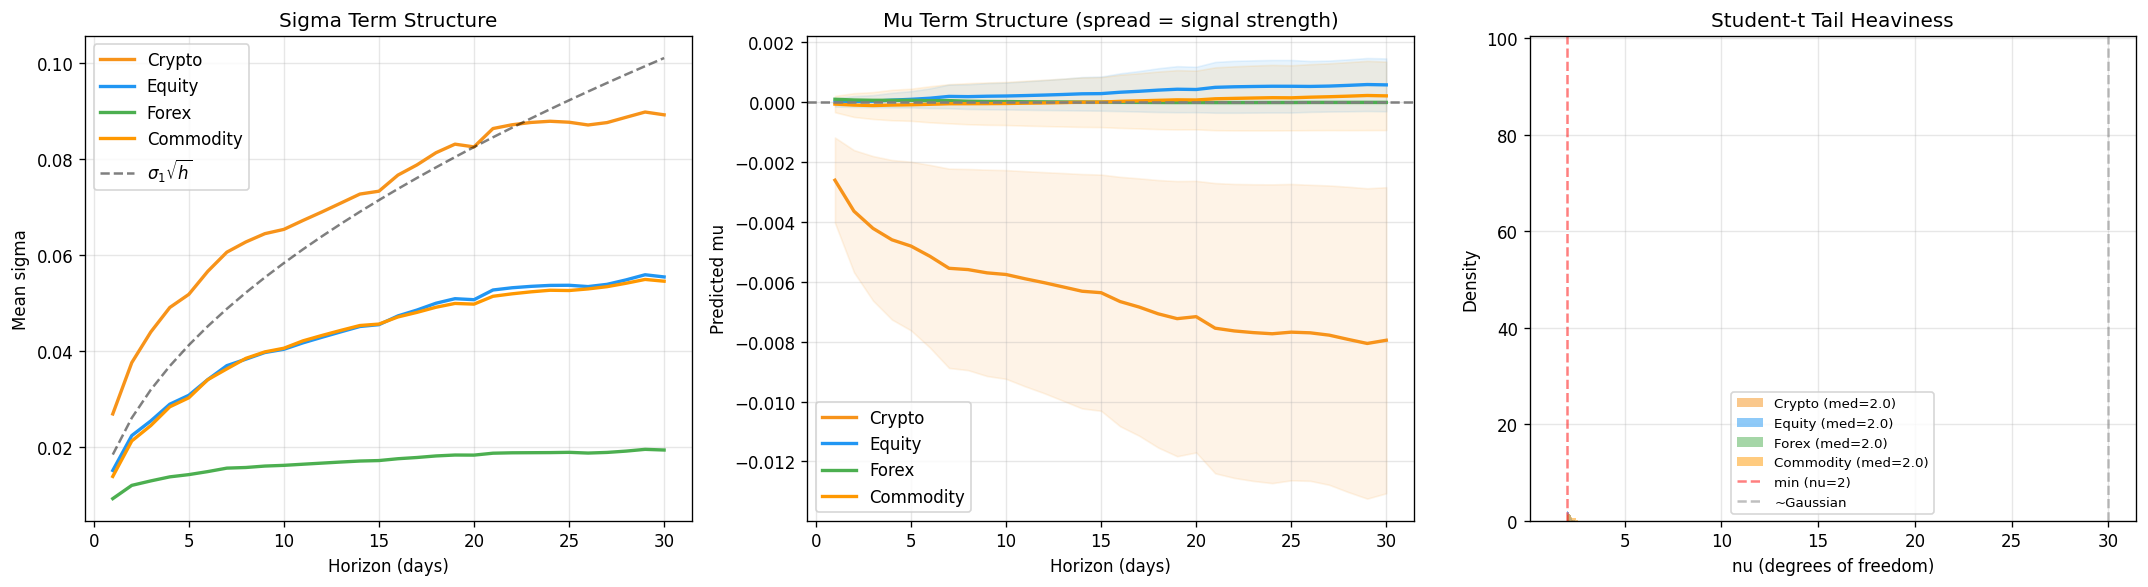

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
h_range = np.arange(1, 31)

# Sigma term structure by asset class
sigma_by_class = sigma_term_structure(sigma, asset_type)
for name, curve in sigma_by_class.items():
    t = [k for k, v in ASSET_NAMES.items() if v == name][0]
    axes[0].plot(h_range, curve, lw=2, color=ASSET_COLORS[t], label=name)
# Theoretical sqrt(h)
overall = sigma.mean(axis=0)
axes[0].plot(h_range, overall[0] * np.sqrt(h_range), 'k--', alpha=0.5, label=r'$\sigma_1\sqrt{h}$')
axes[0].set_xlabel('Horizon (days)'); axes[0].set_ylabel('Mean sigma')
axes[0].set_title('Sigma Term Structure')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Mu term structure by asset class
mu_by_class = mu_term_structure(mu, asset_type)
for name, (mean_curve, std_curve) in mu_by_class.items():
    t = [k for k, v in ASSET_NAMES.items() if v == name][0]
    axes[1].plot(h_range, mean_curve, lw=2, color=ASSET_COLORS[t], label=name)
    axes[1].fill_between(h_range, mean_curve - std_curve, mean_curve + std_curve,
                         alpha=0.1, color=ASSET_COLORS[t])
axes[1].axhline(0, color='gray', ls='--')
axes[1].set_xlabel('Horizon (days)'); axes[1].set_ylabel('Predicted mu')
axes[1].set_title('Mu Term Structure (spread = signal strength)')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

# Nu (degrees of freedom) distribution
nu_stats = nu_distribution(nu, asset_type)
for name, stats in nu_stats.items():
    t = [k for k, v in ASSET_NAMES.items() if v == name][0]
    mask = asset_type == t
    axes[2].hist(nu[mask, h_ref].flatten(), bins=40, alpha=0.5,
                 color=ASSET_COLORS[t], label=f'{name} (med={stats["median"]:.1f})', density=True)
axes[2].axvline(2.01, color='red', ls='--', alpha=0.5, label='min (nu=2)')
axes[2].axvline(30, color='gray', ls='--', alpha=0.5, label='~Gaussian')
axes[2].set_xlabel('nu (degrees of freedom)'); axes[2].set_ylabel('Density')
axes[2].set_title('Student-t Tail Heaviness')
axes[2].legend(fontsize=8); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Temporal Stability of Signal

Is the IC consistent over time, or concentrated in specific periods?

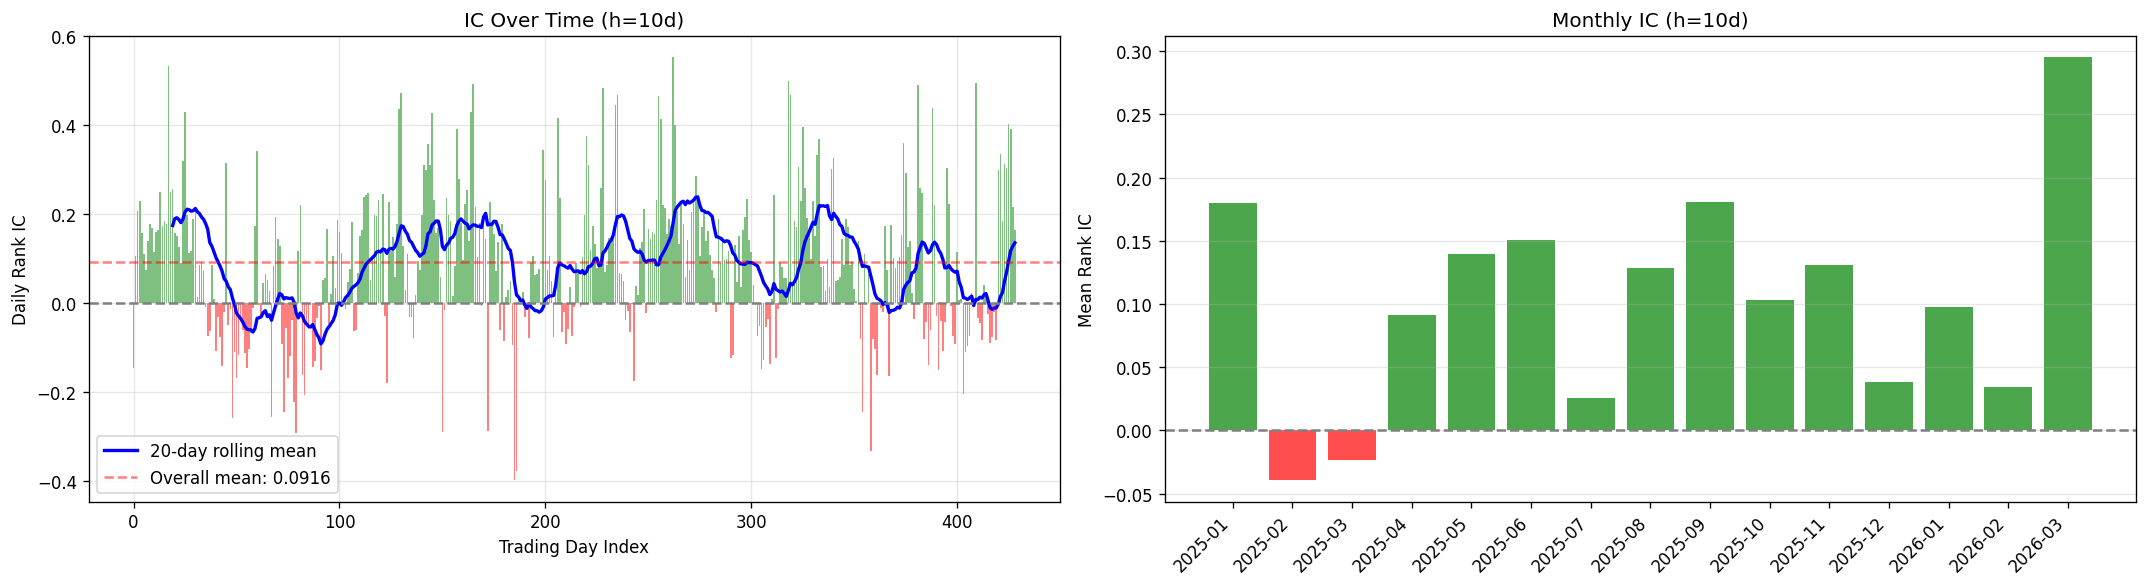

IC positive on 70% of days
Monthly IC positive in 13/15 months


In [11]:
ics_raw, ic_dates, ics_rolling = ic_over_time(mu, Y_rel, dates, h_idx=9, window=20)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

axes[0].bar(range(len(ics_raw)), ics_raw,
            color=['green' if x > 0 else 'red' for x in ics_raw], alpha=0.5)
if len(ics_rolling) > 0:
    offset = len(ics_raw) - len(ics_rolling)
    axes[0].plot(range(offset, offset + len(ics_rolling)), ics_rolling,
                color='blue', lw=2, label=f'20-day rolling mean')
axes[0].axhline(0, color='gray', ls='--')
axes[0].axhline(ics_raw.mean(), color='red', ls='--', alpha=0.5,
                label=f'Overall mean: {ics_raw.mean():.4f}')
axes[0].set_xlabel('Trading Day Index'); axes[0].set_ylabel('Daily Rank IC')
axes[0].set_title('IC Over Time (h=10d)')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Monthly IC
months = np.array([d[:7] for d in ic_dates])
unique_months = sorted(set(months))
monthly_ic = [ics_raw[months == m].mean() for m in unique_months]
colors = ['green' if x > 0 else 'red' for x in monthly_ic]
axes[1].bar(range(len(unique_months)), monthly_ic, color=colors, alpha=0.7)
axes[1].set_xticks(range(len(unique_months)))
axes[1].set_xticklabels(unique_months, rotation=45, ha='right')
axes[1].axhline(0, color='gray', ls='--')
axes[1].set_ylabel('Mean Rank IC'); axes[1].set_title('Monthly IC (h=10d)')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"IC positive on {(ics_raw > 0).mean()*100:.0f}% of days")
print(f"Monthly IC positive in {sum(1 for x in monthly_ic if x > 0)}/{len(monthly_ic)} months")

## 9. Sample Predicted Distributions

Visualize what the model actually outputs for individual assets.

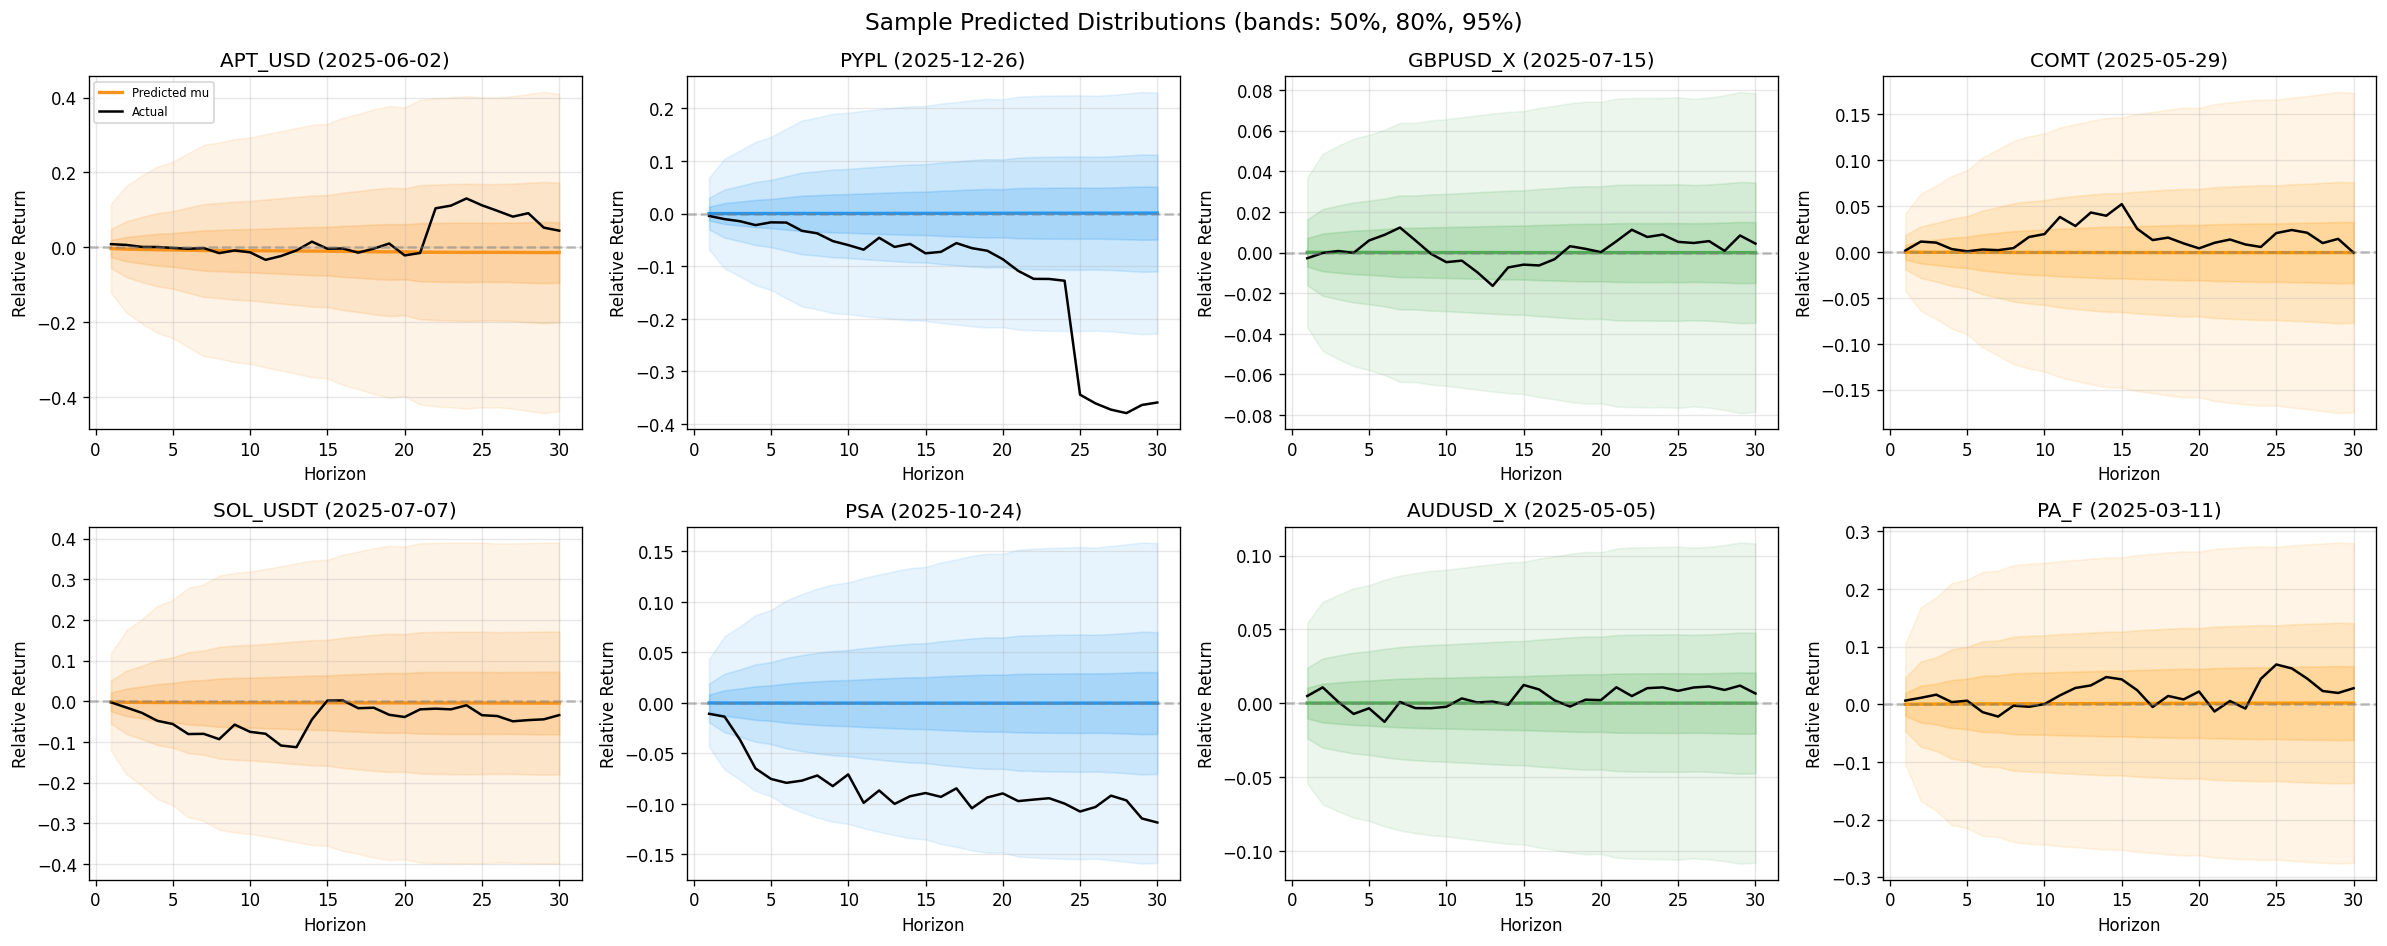

In [12]:
rng = np.random.default_rng(42)
fig, axes = plt.subplots(2, 4, figsize=(20, 8))

for idx, t in enumerate(sorted(np.unique(asset_type))):
    mask = asset_type == t
    samples_idx = rng.choice(np.where(mask)[0], 2, replace=False)
    name = ASSET_NAMES[t]
    
    for j, si in enumerate(samples_idx):
        ax = axes[j, idx]
        h_range = np.arange(1, 31)
        
        # Plot predicted distribution bands
        for level, alpha_fill in [(0.95, 0.1), (0.80, 0.15), (0.50, 0.2)]:
            a = (1 - level) / 2
            lo = scipy_t.ppf(a, df=nu[si], loc=mu[si], scale=sigma[si])
            hi = scipy_t.ppf(1-a, df=nu[si], loc=mu[si], scale=sigma[si])
            ax.fill_between(h_range, lo, hi, alpha=alpha_fill, color=ASSET_COLORS[t])
        
        # Predicted mean
        ax.plot(h_range, mu[si], color=ASSET_COLORS[t], lw=2, label='Predicted mu')
        # Actual relative returns
        ax.plot(h_range, Y_rel[si], 'k-', lw=1.5, label='Actual')
        ax.axhline(0, color='gray', ls='--', alpha=0.5)
        ax.set_xlabel('Horizon'); ax.set_ylabel('Relative Return')
        
        if asset_id is not None:
            aid = str(int(asset_id[si]))
            aname = meta['asset_id_to_name'].get(aid, f'id={aid}')
        else:
            aname = name
        ax.set_title(f'{aname} ({dates[si]})')
        if j == 0 and idx == 0:
            ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)

plt.suptitle('Sample Predicted Distributions (bands: 50%, 80%, 95%)', fontsize=14)
plt.tight_layout()
plt.show()

## 10. Feature Importance (Channel Ablation)

Which of the 6 OHLCV features matter most?

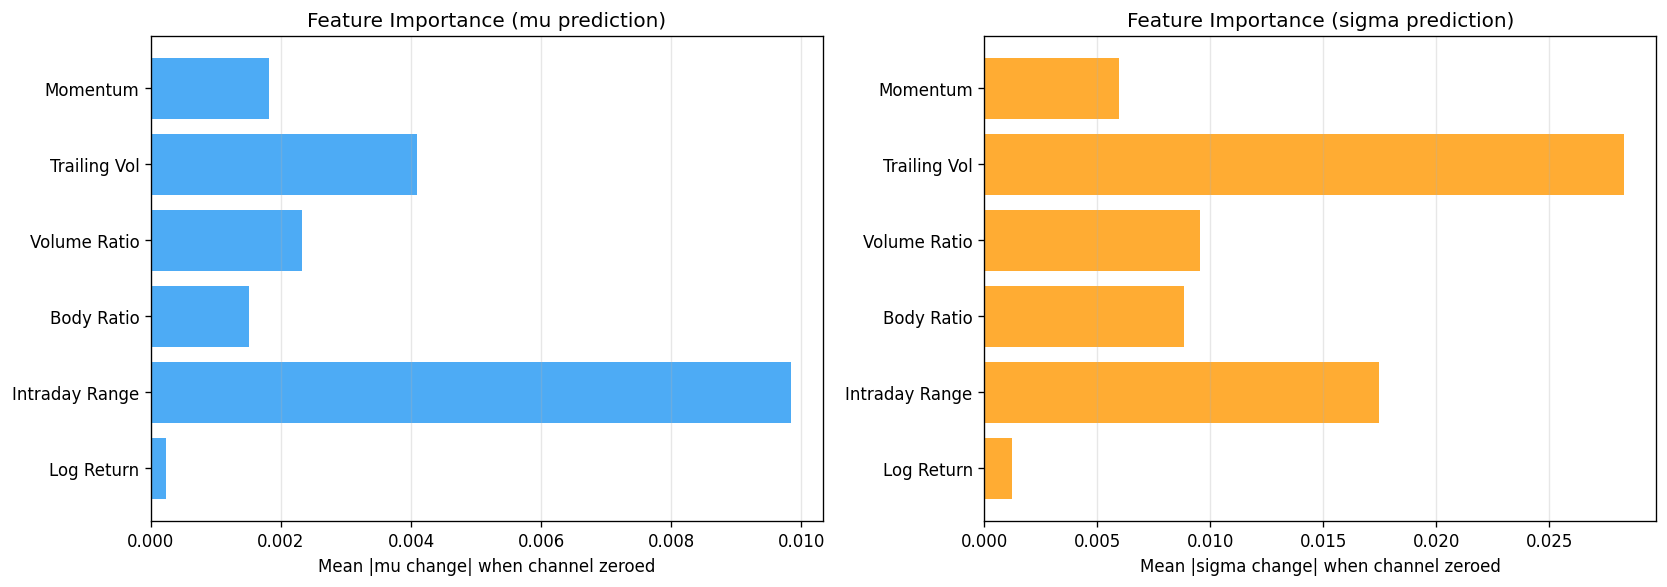

In [13]:
# Use a subsample for speed
X_sub = X[:2000]
importance = feature_importance(model, X_sub)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

names = list(importance.keys())
mu_changes = [importance[n]['mu_change'] for n in names]
sigma_changes = [importance[n]['sigma_change'] for n in names]

axes[0].barh(names, mu_changes, color='#2196F3', alpha=0.8)
axes[0].set_xlabel('Mean |mu change| when channel zeroed')
axes[0].set_title('Feature Importance (mu prediction)')
axes[0].grid(True, alpha=0.3, axis='x')

axes[1].barh(names, sigma_changes, color='#FF9800', alpha=0.8)
axes[1].set_xlabel('Mean |sigma change| when channel zeroed')
axes[1].set_title('Feature Importance (sigma prediction)')
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

## 11. Encoder Representations (t-SNE)

Do different asset classes form clusters in the learned embedding space?

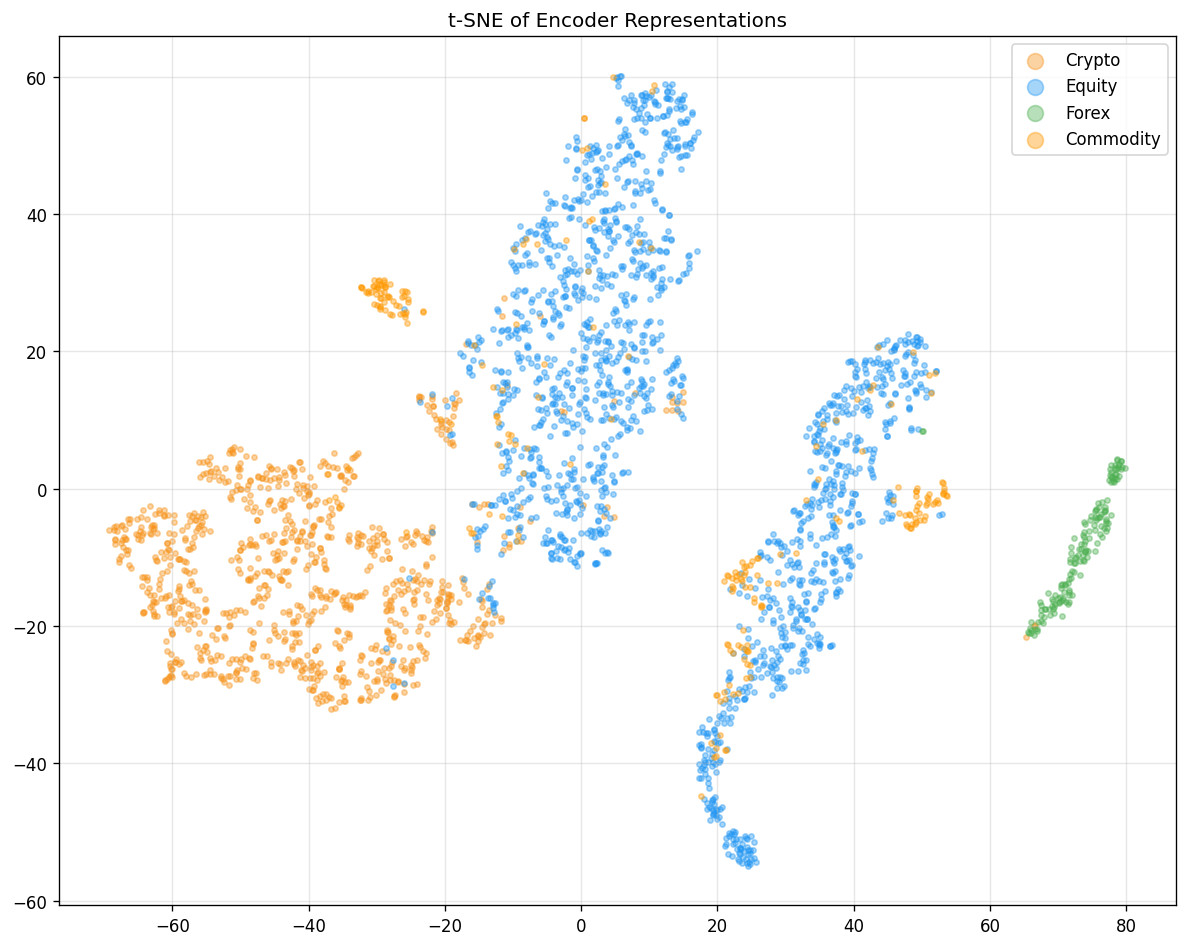

In [14]:
from sklearn.manifold import TSNE

# Subsample for t-SNE
n_tsne = 3000
rng = np.random.default_rng(42)
idx = rng.choice(len(X), n_tsne, replace=False)

embeddings = get_encoder_embeddings(model, X[idx])
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
emb_2d = tsne.fit_transform(embeddings)

fig, ax = plt.subplots(figsize=(10, 8))
for t in sorted(np.unique(asset_type[idx])):
    mask = asset_type[idx] == t
    ax.scatter(emb_2d[mask, 0], emb_2d[mask, 1], alpha=0.4, s=10,
               color=ASSET_COLORS[t], label=ASSET_NAMES[t])
ax.legend(markerscale=3); ax.set_title('t-SNE of Encoder Representations')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 12. Summary

| Metric | Value |
|--------|-------|
| **Rank IC (10d)** | 0.092 |
| **IC t-statistic** | 11.8 |
| **Long-Short Sharpe** | 4.55 |
| **Cumulative L/S** | 431% |
| **Win Rate** | 61% |
| **Crypto IC** | 0.144 |
| **Coverage 90%** | 95.7% |
| **ECE** | ~0.01 |

### Key Findings

1. **Cross-sectional signal exists in OHLCV features** — IC=0.09 at 10d, growing to 0.12 at 30d
2. **Signal is strongest in crypto** (IC=0.14) and commodities (IC=0.08), weak in equities (IC=0.01)
3. **IC increases with horizon** — consistent with drift SNR scaling as sqrt(h)
4. **Distributional calibration is excellent** — PIT near-uniform, coverage well-calibrated
5. **Student-t tails (nu~2)** capture the heavy-tailed nature of relative returns
6. **Absolute returns remain unpredictable** — the signal is purely cross-sectional (relative)